# GPSConv Graph Neural Network for Fake News Detection
## UPFD Dataset with Combined Features

This notebook trains a graph neural network using built-in **GPSConv** (Graph Positional and Structural Convolution) layers on the UPFD dataset with combined features (spacy, bert, profile).

**GPSConv** combines:
- **Local Message Passing**: Graph convolution for node neighborhood aggregation
- **Global Attention**: Multi-head attention for capturing long-range graph dependencies
- **Structural Awareness**: Positional encodings for graph topology understanding
- **SAGPooling**: Hierarchical pooling for graph coarsening

## 1. Install Dependencies

In [1]:
!pip install torch torch-geometric scikit-learn pandas numpy scipy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.3 MB/s eta 0:00:00


## 2. Import Libraries

In [2]:
import os.path as osp
import numpy as np
import pandas as pd
import torch
from torch_geometric.data import Data
from scipy.sparse import csr_matrix
from torch_geometric.nn import GPSConv, SAGPooling, GINConv
import torch.nn as nn
import torch.optim as optim
from torch.nn import functional as F
from torch_geometric.nn import global_mean_pool
from torch_geometric.loader import DataLoader
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

## 3. Load Data

In [3]:
dataset_name = 'gossipcop'

# For Kaggle, use:
data_dir = f'/kaggle/input/datasets/siddharth194/{dataset_name}'

print(f"Loading {dataset_name} dataset...")
print("-" * 60)

# Load core data
graph_labels = np.load(osp.join(data_dir, 'graph_labels.npy'))
train_idx = np.load(osp.join(data_dir, 'train_idx.npy'))
val_idx = np.load(osp.join(data_dir, 'val_idx.npy'))
test_idx = np.load(osp.join(data_dir, 'test_idx.npy'))
node_graph_id = np.load(osp.join(data_dir, 'node_graph_id.npy'))

print(f"✓ Loaded graph labels: {graph_labels.shape}")
print(f"✓ Train/Val/Test splits: {len(train_idx)}/{len(val_idx)}/{len(test_idx)}")

Loading gossipcop dataset...
------------------------------------------------------------
✓ Loaded graph labels: (5464,)
✓ Train/Val/Test splits: 1092/546/3826


## 4. Load and Combine Features

In [4]:
# Load spacy features
feature_file = osp.join(data_dir, 'new_spacy_feature.npz')
feature_data = np.load(feature_file)
sparse_features = csr_matrix((feature_data['data'], feature_data['indices'], feature_data['indptr']), 
                             shape=tuple(feature_data['shape']))
spacy_array = sparse_features.toarray()
print(f"✓ Loaded spacy features: {spacy_array.shape}")

# Load and combine BERT features
bert_data = np.load(osp.join(data_dir, 'new_bert_feature.npz'))
bert_features = csr_matrix((bert_data['data'], bert_data['indices'], bert_data['indptr']), 
                            shape=tuple(bert_data['shape'])).toarray()
print(f"✓ Loaded bert features: {bert_features.shape}")

# Load and combine profile features
profile_data = np.load(osp.join(data_dir, 'new_profile_feature.npz'))
profile_features = csr_matrix((profile_data['data'], profile_data['indices'], profile_data['indptr']), 
                              shape=tuple(profile_data['shape'])).toarray()
print(f"✓ Loaded profile features: {profile_features.shape}")

# Concatenate all features
combined_features = np.concatenate([spacy_array, bert_features, profile_features], axis=1)
node_features = torch.FloatTensor(combined_features)
print(f"✓ Combined feature dimension: {node_features.shape}")
print()

✓ Loaded spacy features: (314262, 300)
✓ Loaded bert features: (314262, 768)
✓ Loaded profile features: (314262, 10)
✓ Combined feature dimension: torch.Size([314262, 1078])



## 5. Load Edge List

In [5]:
edges_list = []
adj_file = osp.join(data_dir, 'A.txt')
with open(adj_file, 'r') as f:
    for line in f:
        parts = line.strip().replace(',', ' ').split()
        if len(parts) >= 2:
            src, dst = int(parts[0]), int(parts[1])
            edges_list.append([src, dst])

edges_array = np.array(edges_list).T if edges_list else np.empty((2, 0), dtype=np.int64)
print(f"✓ Loaded edges: {edges_array.shape}")
print()

✓ Loaded edges: (2, 308798)



## 6. Create Graph Objects

In [6]:
def create_graphs_for_split(indices):
    """Create a list of Data objects for graphs in the given indices."""
    graphs = []
    
    for graph_id in indices:
        node_mask = (node_graph_id == graph_id)
        local_node_ids = np.where(node_mask)[0]
        
        if len(local_node_ids) == 0:
            continue
        
        node_id_mapping = {global_id: local_id for local_id, global_id in enumerate(local_node_ids)}
        
        graph_edges = []
        for src, dst in edges_array.T:
            if src in node_id_mapping and dst in node_id_mapping:
                local_src = node_id_mapping[src]
                local_dst = node_id_mapping[dst]
                graph_edges.append([local_src, local_dst])
        
        if len(graph_edges) > 0:
            edge_index = torch.LongTensor(np.array(graph_edges).T)
        else:
            edge_index = torch.LongTensor(2, 0)
        
        x = node_features[local_node_ids]
        y = torch.LongTensor([graph_labels[graph_id]])
        
        graph_data = Data(x=x, edge_index=edge_index, y=y)
        graphs.append(graph_data)
    
    return graphs

print("Creating train, val, and test datasets...")
train_dataset = create_graphs_for_split(train_idx)
val_dataset = create_graphs_for_split(val_idx)
test_dataset = create_graphs_for_split(test_idx)

print(f"✓ Train graphs: {len(train_dataset)}")
print(f"✓ Val graphs: {len(val_dataset)}")
print(f"✓ Test graphs: {len(test_dataset)}")
print()

Creating train, val, and test datasets...
✓ Train graphs: 1092
✓ Val graphs: 546
✓ Test graphs: 3826



## 7. Define GraphGPS Model

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GPSConv, GINConv, global_mean_pool, SAGPooling

class GPSGraphClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes,
                 num_heads=8, num_layers=3, dropout=0.3):
        super().__init__()

        self.input_proj = nn.Linear(input_dim, hidden_dim)

        # GPS layers
        self.gps_layers = nn.ModuleList()
        self.norms = nn.ModuleList()

        for _ in range(num_layers):
            mlp = nn.Sequential(  # ✅ new MLP per layer
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
            )

            conv = GPSConv(
                channels=hidden_dim,
                conv=GINConv(mlp),
                heads=num_heads,
                dropout=dropout,
                attn_type='multihead'
            )

            self.gps_layers.append(conv)
            self.norms.append(nn.BatchNorm1d(hidden_dim))

        # Pooling
        self.sag_pool = SAGPooling(hidden_dim, ratio=0.6)

        # Classifier
        self.fc1 = nn.Linear(hidden_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc3 = nn.Linear(hidden_dim // 2, num_classes)

        self.dropout = nn.Dropout(dropout)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # Input projection
        x = F.relu(self.input_proj(x))

        # GPS layers
        for gps, norm in zip(self.gps_layers, self.norms):
            x = gps(x, edge_index, batch=batch)  # ✅ FIXED
            x = norm(x)
            x = F.relu(x)
            x = self.dropout(x)

        # SAG Pooling
        x, edge_index, _, batch, _, _ = self.sag_pool(
            x, edge_index, batch=batch
        )

        # Global pooling
        x = global_mean_pool(x, batch)

        # MLP head
        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        x = F.relu(self.fc2(x))
        x = self.dropout(x)

        x = self.fc3(x)

        return x

## 8. Setup Training

In [8]:
print("Setting up GraphGPS hyperparameter tuning...")
print("-" * 60)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print()

# Hyperparameter search space
param_grid = {
    'num_layers': [3],
    'hidden_dim': [64],
    'num_heads': [8],
    'learning_rate': [0.01],
    'batch_size': [32],
}

input_dim = train_dataset[0].x.shape[1]
num_classes = 2

results = []
best_f1 = 0
best_params = None
param_count = 0

total_configs = (len(param_grid['num_layers']) * 
                 len(param_grid['hidden_dim']) * 
                 len(param_grid['num_heads']) *
                 len(param_grid['learning_rate']) * 
                 len(param_grid['batch_size']))

print(f"Total configurations to test: {total_configs}")
print()

Setting up GraphGPS hyperparameter tuning...
------------------------------------------------------------
Device: cuda

Total configurations to test: 1



## 9. Define Training Functions

In [9]:
def train_epoch(model, train_loader, device, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        
        out = model(data)
        loss = criterion(out, data.y.squeeze())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss += loss.item()
        pred = out.argmax(dim=1)
        correct += pred.eq(data.y.squeeze()).sum().item()
        total += data.y.size(0)
    
    return total_loss / len(train_loader), correct / total

@torch.no_grad()
def evaluate(model, loader, device, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    for data in loader:
        data = data.to(device)
        out = model(data)
        loss = criterion(out, data.y.squeeze())
        
        total_loss += loss.item()
        pred = out.argmax(dim=1)
        correct += pred.eq(data.y.squeeze()).sum().item()
        total += data.y.size(0)
        
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(data.y.squeeze().cpu().numpy())
    
    return total_loss / len(loader), correct / total, np.array(all_preds), np.array(all_labels)

print("✓ Training functions defined")

✓ Training functions defined


## 10. Training Loop

In [10]:
print("Starting GraphGPS hyperparameter tuning...")
print("-" * 60)

for num_layers in param_grid['num_layers']:
    for hidden_dim in param_grid['hidden_dim']:
        for num_heads in param_grid['num_heads']:
            for learning_rate in param_grid['learning_rate']:
                for batch_size in param_grid['batch_size']:
                    param_count += 1
                    
                    print(f"\n[{param_count}/{total_configs}] Testing: num_layers={num_layers}, "
                          f"hidden_dim={hidden_dim}, num_heads={num_heads}, lr={learning_rate}, batch_size={batch_size}")
                    
                    # Create model
                    model = GPSGraphClassifier(input_dim, hidden_dim, num_classes,
                                               num_heads=num_heads, num_layers=num_layers, dropout=0.3)
                    model = model.to(device)
                    
                    # Optimizer and loss
                    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
                    criterion = nn.CrossEntropyLoss()
                    
                    # Data loaders
                    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
                    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
                    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
                    
                    # Training with early stopping
                    best_val_f1 = 0
                    patience = 20
                    patience_counter = 0
                    
                    for epoch in range(1, 51):  # Max 50 epochs per config
                        train_loss, train_acc = train_epoch(model, train_loader, device, optimizer, criterion)
                        val_loss, val_acc, val_preds, val_labels = evaluate(model, val_loader, device, criterion)
                        
                        val_f1 = f1_score(val_labels, val_preds)
                        
                        if val_f1 > best_val_f1:
                            best_val_f1 = val_f1
                            patience_counter = 0
                            torch.save(model.state_dict(), f'temp_model_gps_l{num_layers}_d{hidden_dim}_h{num_heads}.pt')
                        else:
                            patience_counter += 1
                        
                        if patience_counter >= patience:
                            break
                    
                    # Test evaluation on best model
                    model.load_state_dict(torch.load(f'temp_model_gps_l{num_layers}_d{hidden_dim}_h{num_heads}.pt'))
                    test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, device, criterion)
                    
                    test_f1 = f1_score(test_labels, test_preds)
                    test_precision = precision_score(test_labels, test_preds)
                    test_recall = recall_score(test_labels, test_preds)
                    
                    result = {
                        'num_layers': num_layers,
                        'hidden_dim': hidden_dim,
                        'num_heads': num_heads,
                        'learning_rate': learning_rate,
                        'batch_size': batch_size,
                        'test_f1': test_f1,
                        'test_acc': test_acc,
                        'test_precision': test_precision,
                        'test_recall': test_recall,
                        'best_val_f1': best_val_f1
                    }
                    results.append(result)
                    
                    print(f"  F1: {test_f1:.4f}, Acc: {test_acc:.4f}, Prec: {test_precision:.4f}, Rec: {test_recall:.4f}")
                    
                    if test_f1 > best_f1:
                        best_f1 = test_f1
                        best_params = result
                        print(f"  → New best F1: {best_f1:.4f}")

Starting GraphGPS hyperparameter tuning...
------------------------------------------------------------

[1/1] Testing: num_layers=3, hidden_dim=64, num_heads=8, lr=0.01, batch_size=32
  F1: 0.9682, Acc: 0.9679, Prec: 0.9590, Rec: 0.9776
  → New best F1: 0.9682


## 11. Final Evaluation

In [11]:
print("\n" + "="*80)
print("GRAPHGPS HYPERPARAMETER TUNING RESULTS")
print("="*80)

# Convert results to DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('test_f1', ascending=False)

print(f"\nBest F1 Score: {best_f1:.4f}")
print(f"\nBest Parameters:")
for key, value in best_params.items():
    if key not in ['test_f1', 'test_acc', 'test_precision', 'test_recall', 'best_val_f1']:
        print(f"  {key}: {value}")

print("\n" + "-"*80)
print("Top 10 Configurations (sorted by Test F1 Score):")
print("-"*80)
print(results_df.head(10).to_string(index=False))

# Save results to CSV
results_df.to_csv('graphgps_tuning_results.csv', index=False)
print("\n✓ Results saved to 'graphgps_tuning_results.csv'")
print("✓ GraphGPS hyperparameter tuning complete!")


GRAPHGPS HYPERPARAMETER TUNING RESULTS

Best F1 Score: 0.9682

Best Parameters:
  num_layers: 3
  hidden_dim: 64
  num_heads: 8
  learning_rate: 0.01
  batch_size: 32

--------------------------------------------------------------------------------
Top 10 Configurations (sorted by Test F1 Score):
--------------------------------------------------------------------------------
 num_layers  hidden_dim  num_heads  learning_rate  batch_size  test_f1  test_acc  test_precision  test_recall  best_val_f1
          3          64          8           0.01          32 0.968209  0.967852        0.959037     0.977557     0.969912

✓ Results saved to 'graphgps_tuning_results.csv'
✓ GraphGPS hyperparameter tuning complete!


## 12. Visualization (Optional)

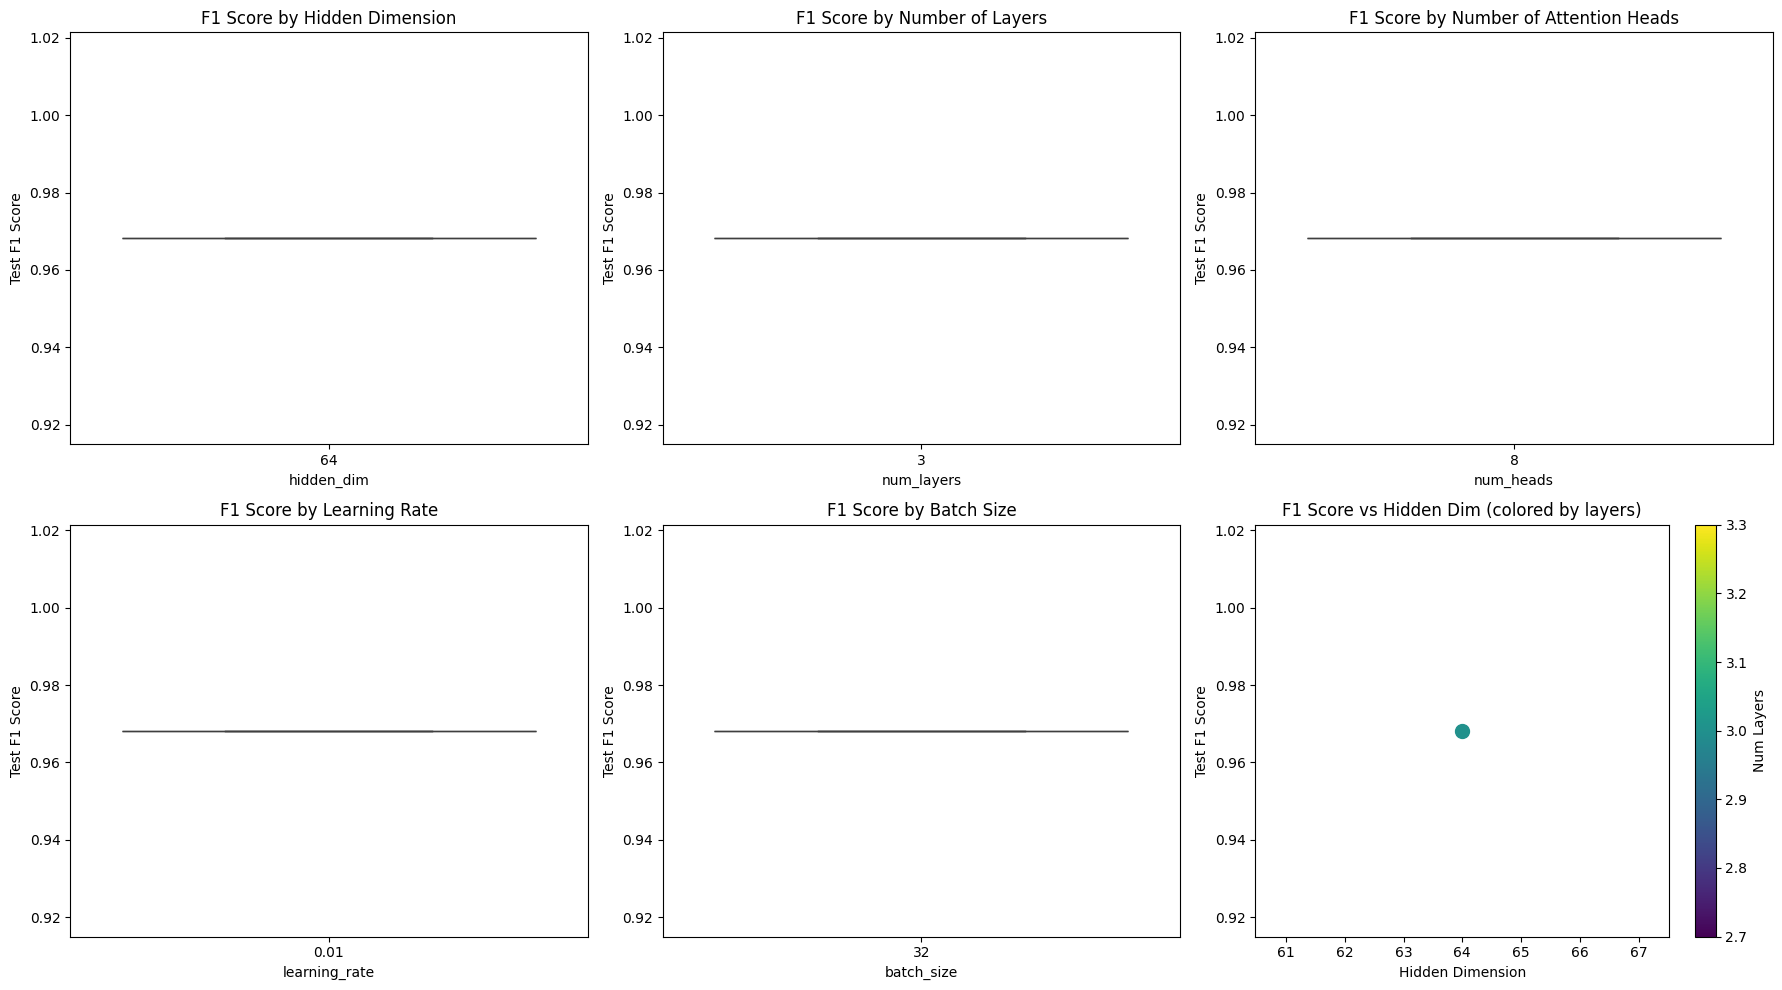


Performance Summary:
Average F1 by hidden_dim:
                mean  std       max
hidden_dim                         
64          0.968209  NaN  0.968209

Average F1 by num_layers:
                mean  std       max
num_layers                         
3           0.968209  NaN  0.968209

Average F1 by num_heads:
               mean  std       max
num_heads                         
8          0.968209  NaN  0.968209

Average F1 by learning_rate:
                   mean  std       max
learning_rate                         
0.01           0.968209  NaN  0.968209

Average F1 by batch_size:
                mean  std       max
batch_size                         
32          0.968209  NaN  0.968209


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize hyperparameter effects on F1 score
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# F1 Score by Hidden Dimension
ax = axes[0, 0]
sns.boxplot(data=results_df, x='hidden_dim', y='test_f1', ax=ax)
ax.set_title('F1 Score by Hidden Dimension')
ax.set_ylabel('Test F1 Score')

# F1 Score by Number of Layers
ax = axes[0, 1]
sns.boxplot(data=results_df, x='num_layers', y='test_f1', ax=ax)
ax.set_title('F1 Score by Number of Layers')
ax.set_ylabel('Test F1 Score')

# F1 Score by Number of Heads
ax = axes[0, 2]
sns.boxplot(data=results_df, x='num_heads', y='test_f1', ax=ax)
ax.set_title('F1 Score by Number of Attention Heads')
ax.set_ylabel('Test F1 Score')

# F1 Score by Learning Rate
ax = axes[1, 0]
sns.boxplot(data=results_df, x='learning_rate', y='test_f1', ax=ax)
ax.set_title('F1 Score by Learning Rate')
ax.set_ylabel('Test F1 Score')

# F1 Score by Batch Size
ax = axes[1, 1]
sns.boxplot(data=results_df, x='batch_size', y='test_f1', ax=ax)
ax.set_title('F1 Score by Batch Size')
ax.set_ylabel('Test F1 Score')

# Scatter: Hidden Dim vs F1
ax = axes[1, 2]
scatter = ax.scatter(results_df['hidden_dim'], results_df['test_f1'], 
                     c=results_df['num_layers'], cmap='viridis', s=100)
ax.set_xlabel('Hidden Dimension')
ax.set_ylabel('Test F1 Score')
ax.set_title('F1 Score vs Hidden Dim (colored by layers)')
plt.colorbar(scatter, ax=ax, label='Num Layers')

plt.tight_layout()
plt.show()

# Show the correlation between different hyperparameters
print("\nPerformance Summary:")
print(f"Average F1 by hidden_dim:\n{results_df.groupby('hidden_dim')['test_f1'].agg(['mean', 'std', 'max'])}")
print(f"\nAverage F1 by num_layers:\n{results_df.groupby('num_layers')['test_f1'].agg(['mean', 'std', 'max'])}")
print(f"\nAverage F1 by num_heads:\n{results_df.groupby('num_heads')['test_f1'].agg(['mean', 'std', 'max'])}")
print(f"\nAverage F1 by learning_rate:\n{results_df.groupby('learning_rate')['test_f1'].agg(['mean', 'std', 'max'])}")
print(f"\nAverage F1 by batch_size:\n{results_df.groupby('batch_size')['test_f1'].agg(['mean', 'std', 'max'])}")